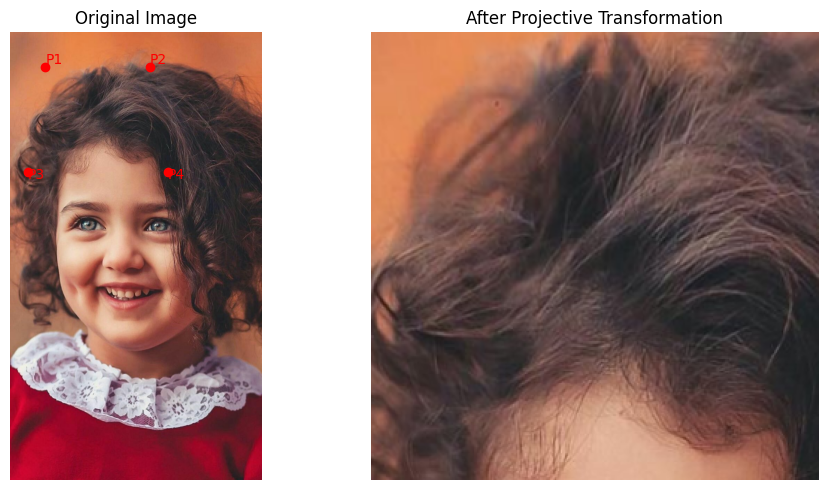

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Step 1: Load Image ---
image = cv2.imread("pk.jpg")
if image is None:
    raise FileNotFoundError("Image not found. Please make sure 'pk.jpg' is in this folder.")

# Convert to RGB for display in matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# --- Step 2: Define 4 Points (source) on the input image ---
# (You can find these by hovering in an image editor like Paint or OpenCV window)
pts_src = np.float32([[100, 100],   # top-left
                      [400, 100],   # top-right
                      [50, 400],    # bottom-left
                      [450, 400]])  # bottom-right

# --- Step 3: Define 4 Destination Points (target view) ---
# This will map the selected quadrilateral into a rectangle
pts_dst = np.float32([[0, 0],
                      [300, 0],
                      [0, 300],
                      [300, 300]])

# --- Step 4: Compute the Projective Transformation Matrix ---
M = cv2.getPerspectiveTransform(pts_src, pts_dst)

# --- Step 5: Apply the Perspective Warp ---
warped = cv2.warpPerspective(image_rgb, M, (300, 300))

# --- Step 6: Display Results ---
plt.figure(figsize=(10, 5))

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title('Original Image')
plt.scatter(pts_src[:, 0], pts_src[:, 1], color='red', marker='o')
plt.text(pts_src[0][0], pts_src[0][1] - 10, "P1", color='red')
plt.text(pts_src[1][0], pts_src[1][1] - 10, "P2", color='red')
plt.text(pts_src[2][0], pts_src[2][1] + 20, "P3", color='red')
plt.text(pts_src[3][0], pts_src[3][1] + 20, "P4", color='red')
plt.axis('off')

# Warped (Projected) Image
plt.subplot(1, 2, 2)
plt.imshow(warped)
plt.title('After Projective Transformation')
plt.axis('off')

plt.tight_layout()
plt.show()


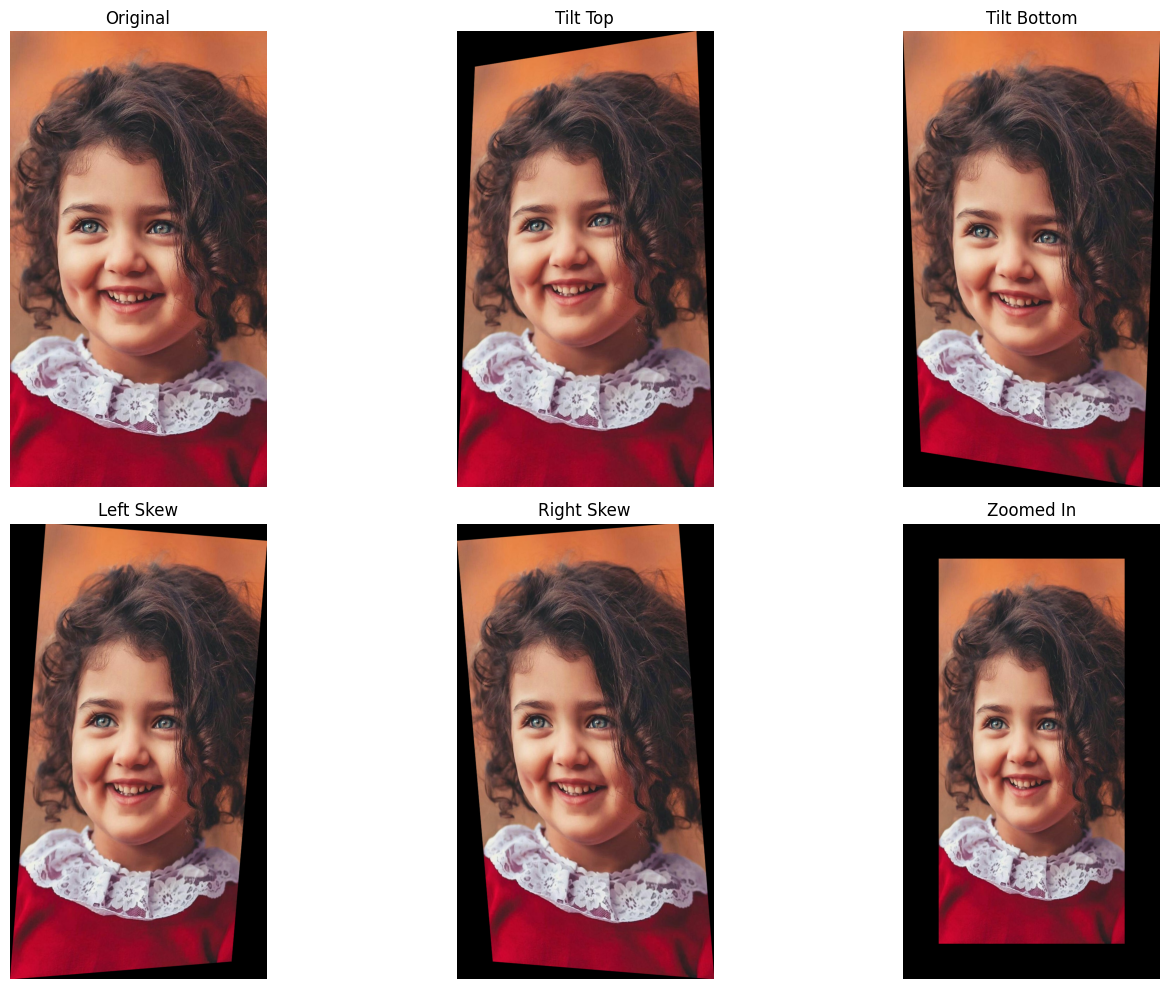

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Step 1: Load Image ---
image = cv2.imread("pk.jpg")
if image is None:
    raise FileNotFoundError("Image not found! Please place 'pk.jpg' in this folder.")

# Convert BGR → RGB for display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
h, w = image_rgb.shape[:2]

# --- Step 2: Define Original Corner Points ---
src_pts = np.float32([[0, 0], [w - 1, 0], [0, h - 1], [w - 1, h - 1]])

# --- Step 3: Define Multiple Destination Point Sets for Different Transformations ---

# A) Normal (no change)
dst_normal = np.float32([[0, 0], [w - 1, 0], [0, h - 1], [w - 1, h - 1]])

# B) Tilted Top (simulate camera looking from above)
dst_tilt_top = np.float32([[50, 100], [w - 50, 0], [0, h - 1], [w, h - 1]])

# C) Tilted Bottom (simulate looking from below)
dst_tilt_bottom = np.float32([[0, 0], [w, 0], [50, h - 100], [w - 50, h - 1]])

# D) Left Perspective (skew left)
dst_left = np.float32([[100, 0], [w, 50], [0, h], [w - 100, h - 50]])

# E) Right Perspective (skew right)
dst_right = np.float32([[0, 50], [w - 100, 0], [100, h - 50], [w, h]])

# F) Zoomed (narrow field)
dst_zoom = np.float32([[100, 100], [w - 100, 100], [100, h - 100], [w - 100, h - 100]])

# --- Step 4: Function to Apply Perspective Transformation ---
def perspective_transform(image, src, dst, size=(400, 400)):
    matrix = cv2.getPerspectiveTransform(src, dst)
    warped = cv2.warpPerspective(image, matrix, size)
    return warped

# --- Step 5: Apply All Transformations ---
results = {
    "Original": image_rgb,
    "Tilt Top": perspective_transform(image_rgb, src_pts, dst_tilt_top, (w, h)),
    "Tilt Bottom": perspective_transform(image_rgb, src_pts, dst_tilt_bottom, (w, h)),
    "Left Skew": perspective_transform(image_rgb, src_pts, dst_left, (w, h)),
    "Right Skew": perspective_transform(image_rgb, src_pts, dst_right, (w, h)),
    "Zoomed In": perspective_transform(image_rgb, src_pts, dst_zoom, (w, h)),
}

# --- Step 6: Display All Results ---
plt.figure(figsize=(15, 10))
for i, (title, img) in enumerate(results.items()):
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.show()


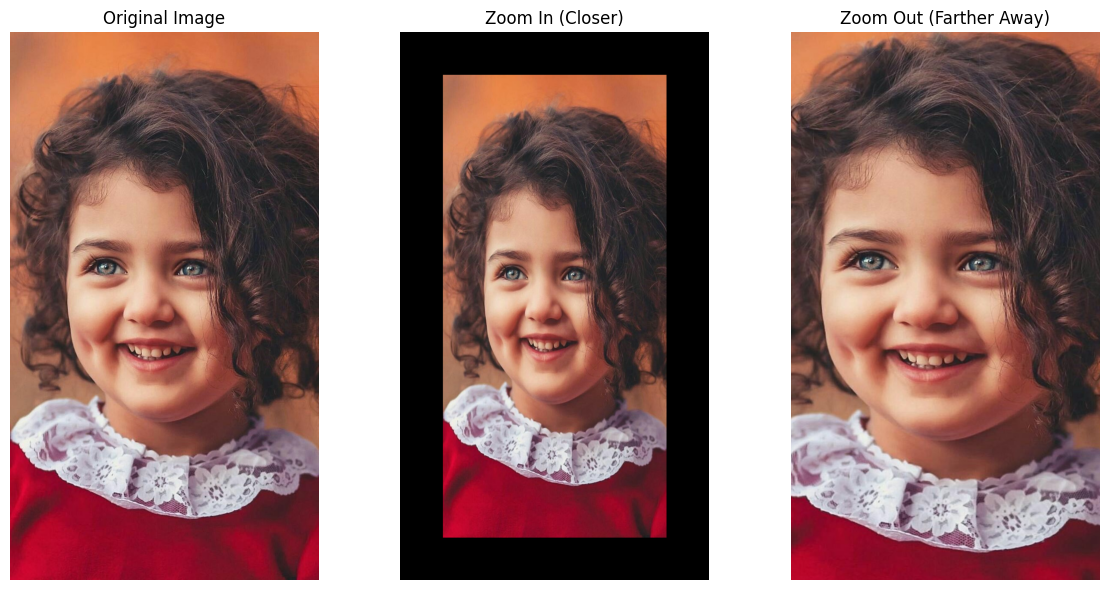

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Step 1: Load Image ---
image = cv2.imread("pk.jpg")
if image is None:
    raise FileNotFoundError("Image not found! Please place 'pk.jpg' in this folder.")

# Convert BGR → RGB for matplotlib display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
h, w = image_rgb.shape[:2]

# --- Step 2: Define Original Corner Points ---
src_pts = np.float32([[0, 0], [w - 1, 0], [0, h - 1], [w - 1, h - 1]])

# --- Step 3: Define Perspective Transformations ---

# A) Zoom In (image appears closer)
dst_zoom_in = np.float32([
    [100, 100], [w - 100, 100],
    [100, h - 100], [w - 100, h - 100]
])

# B) Zoom Out (image appears smaller, surrounded by background)
dst_zoom_out = np.float32([
    [-100, -100], [w + 100, -100],
    [-100, h + 100], [w + 100, h + 100]
])

# --- Step 4: Function for Perspective Transform ---
def perspective_transform(image, src, dst, size):
    M = cv2.getPerspectiveTransform(src, dst)
    warped = cv2.warpPerspective(image, M, size)
    return warped

# --- Step 5: Apply Zoom In and Zoom Out ---
zoom_in = perspective_transform(image_rgb, src_pts, dst_zoom_in, (w, h))
zoom_out = perspective_transform(image_rgb, src_pts, dst_zoom_out, (w, h))

# --- Step 6: Display Results ---
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(zoom_in)
plt.title("Zoom In (Closer)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(zoom_out)
plt.title("Zoom Out (Farther Away)")
plt.axis('off')

plt.tight_layout()
plt.show()
